In [17]:
import matplotlib.pyplot as plt


def plot_sample(x, c, y, root, idx):
    plt.figure(figsize=(4, 1))
    plt.subplot(1, 3, 1)
    plt.imshow(x[0], cmap='gray')
    plt.axis('off')

    plt.suptitle(f"{c} = {y}")
    plt.tight_layout()
    #plt.savefig(os.path.join(root, f"sample_{idx}.png"))
    plt.show()
    plt.close()

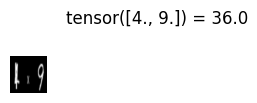

In [19]:
# analysing the arith mnist dataset
#loading the dataset and plotting some examples
import os
import sys
sys.path.append(os.path.abspath(".."))


from cbmc.data.arithmetic_mnist import ArithmeticMNISTDataset


data = ArithmeticMNISTDataset(mnist_root="data/generated/MNIST", num_samples=10, img_size=224, operators=('x', '/'))
for idx in range(1):
    x, c, y = data[idx]
    plot_sample(x, c, y, "figs/mnist_arithmetic_examples", idx) 


In [ ]:
# iterating through tehh mnsit daatset and generating all possible combinations



import torch
import random
from torchvision.datasets import MNIST
from matplotlib import pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw, ImageFont
import torchvision.transforms as T
import numpy as np

import sys
import os

sys.path.append(os.path.join(os.path.dirname(__file__), '..'))
#Sfrom env import HOME, DATA_PATH
DATA_PATH = "data/generated"
HOME = "data"


CONCEPT_NAMES = ["first_digit", "second_digit"]


class ArithmeticMNISTDataset(Dataset):
    def __init__(
            self, 
            mnist_root="./data", 
            train=True, 
            num_samples=10000, 
            img_size=224, 
            operators=('+', '-', 'x', '/'), 
            transform=None,
            incomplete_training=False
        ):

        self.num_samples = num_samples
        self.img_size = img_size
        self.operators = operators

        # generate the list of operators for each sample
        self.operator_list = [random.choice(self.operators) for _ in range(num_samples)]

        # If True, the training set will be composed of a limited set of digit pairs.
        self.incomplete_training = incomplete_training

        # Load MNIST (only digits, no transforms -> we'll handle later)
        self.mnist = datasets.MNIST(root=mnist_root, train=train, download=True, transform=None)

        # Default transforms: resize -> RGB -> tensor
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.Grayscale(num_output_channels=3),
                transforms.ToTensor(),
            ])
        else:
            self.transform = transform

        # Load font for operator symbols
        try:
            self.font = ImageFont.truetype("arial.ttf", 200)
        except:
            self.font = ImageFont.load_default()

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Sample two random MNIST digits, resampling if either is 0
        i1 = random.randint(0, len(self.mnist) - 1)
        i2 = random.randint(0, len(self.mnist) - 1)
        img1, a = self.mnist[i1]
        img2, b = self.mnist[i2]
        
        # Resample if either digit is 0
        while a == 0 or b == 0:
            if a == 0:
                i1 = random.randint(0, len(self.mnist) - 1)
                img1, a = self.mnist[i1]
            if b == 0:
                i2 = random.randint(0, len(self.mnist) - 1)
                img2, b = self.mnist[i2]

        op = self.operator_list[idx]

        # Compute result + flags
        if op == '+':
            result = a + b
            flags = [1, 0, 0, 0]
        elif op == '-':
            result = a - b
            flags = [0, 1, 0, 0]
        elif op == 'x':
            result = a * b
            flags = [0, 0, 1, 0]
        elif op == '/':
            result = a / b
            flags = [0, 0, 0, 1]

        # Make a canvas to paste digits + operator
        canvas = Image.new("L", (84, 28), color=255)  # wide canvas
        canvas.paste(img1, (0, 0))  # left digit
        
        # Create operator symbol with black background and white text
        op_canvas = Image.new("L", (28, 28), color=0)  # black background
        draw = ImageDraw.Draw(op_canvas)
        
        # Get text size for centering
        try:
            bbox = draw.textbbox((0, 0), op, font=self.font)
            text_width = bbox[2] - bbox[0]
            text_height = bbox[3] - bbox[1]
        except AttributeError:
            text_width, text_height = draw.textsize(op, font=self.font)
        
        # Center the text
        x_pos = (28 - text_width) // 2
        y_pos = (28 - text_height) // 2
        draw.text((x_pos, y_pos), op, fill=255, font=self.font)  # white text
        
        canvas.paste(op_canvas, (28, 0))  # paste operator in middle
        canvas.paste(img2, (56, 0))  # right digit

        # Transform to final size
        x = self.transform(canvas)

        # Concept tensor
        c = torch.tensor([a, b], dtype=torch.float32)

        return x, c, torch.tensor(result)



